# 1. 데이터 불러오기

In [4]:
import yfinance as yf
from datetime import date, timedelta

year = 5
today = date.today()
end_date = today.strftime("%Y-%m-%d")
start_date = (today - timedelta(days=year*365))
print(start_date, end_date)

data = yf.download(
    tickers = "009450.KS",
    start=start_date,
    end=end_date
)

data

C:\Users\user\AppData\Local\Temp\ipykernel_46168\2570486427.py:10: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(
[*********************100%***********************]  1 of 1 completed

2020-09-09 2025-09-08


Price,Close,High,Low,Open,Volume
Ticker,009450.KS,009450.KS,009450.KS,009450.KS,009450.KS
Date,,,,,
2020-09-09,54533.328125,55294.700943,53391.268897,55104.357739,154018
2020-09-10,57102.957031,58816.045742,55009.181940,55389.868320,384979
2020-09-11,57293.300781,58054.673549,55389.868862,56531.928013,153445
2020-09-14,55865.726562,57293.300495,55580.211776,57293.300495,125104
2020-09-15,56246.417969,56531.932781,54438.157493,55865.731553,107441
...,...,...,...,...,...
2025-09-01,78200.000000,80200.000000,76900.000000,77500.000000,66416
2025-09-02,77200.000000,79200.000000,76500.000000,79100.000000,44072


In [5]:
data.columns = data.columns.droplevel(1)
data.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2020-09-09,54533.328125,55294.700943,53391.268897,55104.357739,154018
2020-09-10,57102.957031,58816.045742,55009.181940,55389.868320,384979
2020-09-11,57293.300781,58054.673549,55389.868862,56531.928013,153445
2020-09-14,55865.726562,57293.300495,55580.211776,57293.300495,125104
2020-09-15,56246.417969,56531.932781,54438.157493,55865.731553,107441


In [10]:
df = data[["Close"]]
df.head()

Price,Close
Date,
2020-09-09,54533.328125
2020-09-10,57102.957031
2020-09-11,57293.300781
2020-09-14,55865.726562
2020-09-15,56246.417969


In [7]:
# uv add scikit-learn
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

print(device)

cuda


# 2. 데이터 분할

In [11]:
N = len(df)
test_ratio = 0.2
val_ratio = 0.1

test_size = int(N * test_ratio)
val_size = int(N * val_ratio)
train_size = N - test_size - val_size

train_data = df.iloc[:train_size]
val_data = df.iloc[train_size:(train_size + val_size)]
test_data = df.iloc[(train_size + val_size):]

print(f"Train Data Size: {train_data.shape}")
print(f"Val Data Size: {val_data.shape}")
print(f"Test Data Size: {test_data.shape}")


Train Data Size: (857, 1)
Val Data Size: (122, 1)
Test Data Size: (244, 1)


# 3. 데이터 스케일러 적용

In [ ]:
from sklearn.preprocessing import MinMaxScaler

# 질문 1. minmaxscaler란? 데이터를 0~1 사이의 값으로 정규화하는것 가장 작은 값은 0 가장 큰값은 1
# 질문 2. validation data와 test data는 train으로 fitting 시킨 mim max scaler로 정규화해야한다. 그렇지 않으면 정규화하는 의미x
mms = MinMaxScaler()

train_scaled = mms.fit_transform(train_data)
val_scaled = mms.transform(val_data)
test_scaled = mms.transform(test_data)

print(f"train_scaled: {type(train_data)}")
print(f"train_scaled: {type(train_scaled)}")
print(f"train_scaled: {train_scaled.dtype}")


print(f"Scale 범위: min{mms.data_min_}, max{mms.data_max_}")

train_scaled: <class 'pandas.core.frame.DataFrame'>
train_scaled: <class 'numpy.ndarray'>
train_scaled: float64
Scale 범위: min[32080.44335938], max[74072.03125]


# 4. 학습 데이터

In [18]:
train_scaled.shape

(857, 1)

In [27]:
window = 7
for i in range(0, 14 - window):
    print(i, i+window)
    print(i+window)

0 7
7
1 8
8
2 9
9
3 10
10
4 11
11
5 12
12
6 13
13


In [48]:
#concatenate

import numpy as np
a = np.array([[1, 2],[3, 4]])
b = np.array([[7, 8], [9, 10], [11, 12]])

print(np.concatenate((a,b), axis=0))

[[ 1  2]
 [ 3  4]
 [ 7  8]
 [ 9 10]
 [11 12]]


In [56]:
# window
import numpy as np

# 질문 1. Window 가 무엇을 의미하는지 설명 - 시계열데이터에서 학습에 사용할 입력 데이터로, 사용할 과거 시점의 범위를 지정할 수 있는 변수
        # window=60 -> 과거 60개 시점의 데이터를 입력, 그다음 61 번째를 예측

# 질문 2. train data가 몇개 나오는지 설명 - train_data에서 window 개수를 뺀 만큼의 데이터를 가진다.
        # 전체 데이터 N 개일 때, 샘플 개수는 N-window
def make_dataset(data, window):
    dataX = []
    dataY = []

    for i in range(0, data.shape[0] - window):
        x = data[i:(i + window), :]
        y = data[(i + window), [-1]] #여러 열이어도 맨 오른쪽 열을 가져올수 있도록 [-1]을 해준것
        if i % 100 == 0:
            print(x)
            print(y)
        dataX.append(x)
        dataY.append(y)

    return np.array(dataX), np.array(dataY)

x_train, y_train = make_dataset(train_scaled, window=60)
# val_scaled의 x,y를 만들기 위해서는 train_scaled에서 맨 뒤에서 window만큼을 가져와야한다.
x_val, y_val = make_dataset(np.concatenate([train_scaled[-window:], val_scaled]), window=60)
x_test, y_test = make_dataset(np.concatenate([val_scaled[-window:], test_scaled]), window=60)



[[0.53469959]
 [0.59589349]
 [0.60042639]
 [0.56642972]
 [0.57549561]
 [0.56642972]
 [0.51430153]
 [0.51656798]
 [0.47577196]
 [0.45764035]
 [0.4735056 ]
 [0.43724248]
 [0.38058129]
 [0.43950893]
 [0.43044312]
 [0.48483785]
 [0.49163721]
 [0.48483785]
 [0.51203517]
 [0.51883443]
 [0.51883443]
 [0.48710421]
 [0.4780385 ]
 [0.45764035]
 [0.45990689]
 [0.46670625]
 [0.48937066]
 [0.46670625]
 [0.4644397 ]
 [0.41457797]
 [0.42137732]
 [0.43950893]
 [0.43724248]
 [0.43724248]
 [0.44404174]
 [0.44404174]
 [0.43270957]
 [0.44177538]
 [0.45990689]
 [0.50070292]
 [0.56642972]
 [0.52790024]
 [0.48937066]
 [0.48937066]
 [0.48710421]
 [0.46670625]
 [0.4689726 ]
 [0.48710421]
 [0.48710421]
 [0.4780385 ]
 [0.49390347]
 [0.49843656]
 [0.4689726 ]
 [0.45310754]
 [0.44177538]
 [0.44857464]
 [0.44630828]
 [0.44404174]
 [0.42364386]
 [0.41457797]]
[0.42591013]
[[0.34050686]
 [0.33822478]
 [0.34849377]
 [0.35648058]
 [0.39755633]
 [0.40440229]
 [0.41124824]
 [0.43406811]
 [0.44091406]
 [0.42722215]
 [0.42

In [58]:
print(x_train.shape, y_train.shape)
print(x_val.shape, y_val.shape)
print(x_test.shape, y_test.shape)

(797, 60, 1) (797, 1)
(69, 60, 1) (69, 1)
(191, 60, 1) (191, 1)


In [45]:
import torch
#numpy 배열을 tensor로 변환하는 코드

x_train_ts = torch.FloatTensor(x_train)
y_train_ts = torch.FloatTensor(y_train)

x_val_ts = torch.FloatTensor(x_val)
y_val_ts = torch.FloatTensor(y_val)

x_test_ts = torch.FloatTensor(x_test)
y_test_ts = torch.FloatTensor(y_test)

In [49]:
from torch.utils.data import TensorDataset, DataLoader


train_dataset = TensorDataset(x_train_ts, y_train_ts)
print(len(train_dataset))
#print(dataset[0])

val_dataset = TensorDataset(x_val_ts, y_val_ts)
print(len(val_dataset))

test_dataset = TensorDataset(x_test_ts, y_test_ts)
print(len(test_dataset))
#test_dataset[0]

797
69
191


In [ ]:
#질문1 dataloader가 뭔가요? 데이터를 지정한 미니배치 사이즈로 나누어주는 tensor의 라이브러리
batch_size = 50

train_dataloader = DataLoader(train_dataset, batch_size=batch_size)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
test_dataloader = DataLoader(test_dataset, batch_size=batch_size)


In [55]:
#학습 과정: 한 epoch마다 진행되는 학습 과정을 step별로 설명해주세요

# 순전파: 모델이 예측 값 생성
# 손실계산: 오차 값을 계산
# 역전파: 오차함수를 파라미터에 대해 미분해서 각 가중치의 기울기를 계산
# 가중치 업데이트: 최적화 함수가 기울기를 통해 가중치 한 스텝 업데이트(이동)

In [54]:
next(iter(train_dataloader))[0].shape
next(iter(train_dataloader))[1].shape

torch.Size([50, 1])

# 5. 모델 만들기

In [63]:
import torch.nn as nn 

class LSTMRegressor(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, dropout):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True, #배치 사이즈를 맞춰주세요?
            dropout= dropout if num_layers > 1 else 0
        )
        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        # out: 모든 시점의 요약
        # hn: "마지막 시점"의 Hidden State
        # cn: "마지막 시점"의 Cell State
        out, (hn, cn) = self.lstm(x)
        pred = self.fc(hn[-1])
        return pred
    

In [88]:
# 모델 만들기
model = LSTMRegressor(
    input_size=1,
    hidden_size=128,
    num_layers=2,
    dropout=0.2
)


# 6. 학습하기

In [89]:
# 정의
lr = 1e-3
criterion = nn.MSELoss() # 손실함수
optimizer = torch.optim.Adam(model.parameters(), lr=lr)# 최적화함수
epochs = 50 # epoch

device = "cuda" if torch.cuda.is_available() else "cpu"

model.to(device)
print(device)


cuda


In [90]:
import tqdm

best_val_loss = float("inf")
patience = 5
counter = 0
train_loss_history = []
val_loss_history = []

for epoch in range(epochs):

    # Train
    model.train()

    train_loss = []

    for data, target in tqdm.tqdm(train_dataloader):
        data = data.to(device)
        target = target.to(device)

        optimizer.zero_grad()
        pred = model(data)
        loss = criterion(pred, target)

        loss.backward()
        optimizer.step()

        train_loss.append(loss.item())

    train_loss_history.append(np.mean(train_loss))

    # Validation
    model.eval()
    val_loss = []
    with torch.no_grad():
        for data, target in val_dataloader:
            data = data.to(device)
            target = target.to(device)

            pred = model(data)
            loss = criterion(pred,target)

            val_loss.append(loss.item())

    val_loss_history.append(np.mean(val_loss))

    #출력
    mean_train_loss = float(np.mean(train_loss))
    mean_val_loss = float(np.mean(val_loss))

    print(f"Epoch: {epoch}, train_loss={mean_train_loss:.4f}, val_loss={mean_val_loss:.4f}")

    if mean_val_loss < best_val_loss:
        best_val_loss = mean_val_loss
        counter = 0
        torch.save(model.state_dict(), "best_lstm.pth")

    else:
        counter += 1

        if counter >= patience:
            break
torch.save(model.state_dict(), "last_lstm.pth")

100%|██████████| 16/16 [00:00<00:00, 43.77it/s]


Epoch: 0, train_loss=0.1190, val_loss=0.1772


100%|██████████| 16/16 [00:00<00:00, 58.01it/s]


Epoch: 1, train_loss=0.0624, val_loss=0.1094


100%|██████████| 16/16 [00:00<00:00, 82.69it/s]


...

Epoch: 13, train_loss=0.0026, val_loss=0.0116

100%|██████████| 16/16 [00:00<00:00, 114.28it/s]


Epoch: 14, train_loss=0.0029, val_loss=0.0168


100%|██████████| 16/16 [00:00<00:00, 104.93it/s]

Epoch: 15, train_loss=0.0032, val_loss=0.0131


## 7. 시각화

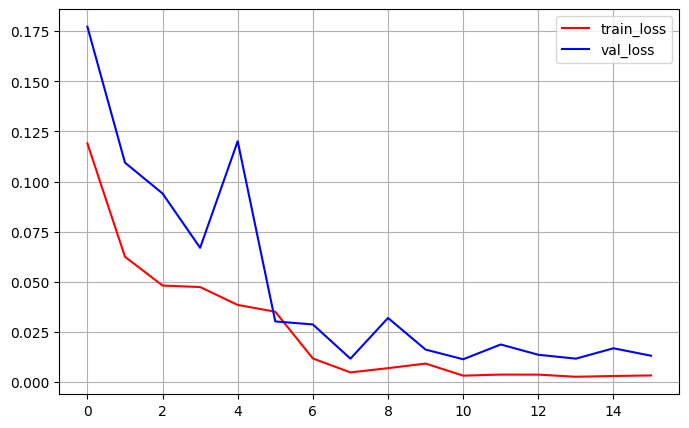

In [93]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(train_loss_history, label="train_loss", color="red")
plt.plot(val_loss_history, label="val_loss", color="blue")
plt.legend()
plt.grid()
plt.show()

## 8. 모델 평가

In [92]:
model.eval()
test_loss_history = []
with torch.no_grad():
    for data, target in test_dataloader:
        data = data.to(device)
        target = target.to(device)

        pred = model(data)
        loss = criterion(pred,target)

        test_loss_history.append(loss.item())


mean_test_loss = float(np.mean(test_loss_history))
print(f"test loss: {mean_test_loss:.4f}")

test loss: 0.0132


## 9. 예측 시각화


In [94]:
x_test_ts = torch.FloatTensor(x_test)
y_test_ts = torch.FloatTensor(y_test)

pred_history = []
for i in range(len(x_test_ts)):
    with torch.no_grad():
        data = x_test_ts[i].to(device)
        pred = model(data.unsqueeze(0))

        print(pred.item())
        pred_history.append(pred.item())


1.2401933670043945
1.212766408920288
1.1840331554412842
1.1597065925598145
1.141245722770691
1.1197999715805054
1.0915930271148682
1.0766607522964478
1.0663995742797852
1.0635777711868286
1.060894250869751
1.0541399717330933
1.049958348274231
1.0612772703170776
1.0803025960922241
1.0993255376815796
1.1244648694992065
1.144357442855835
1.1647534370422363
1.1847474575042725
1.2032196521759033
1.2202537059783936
1.2341053485870361
1.2450575828552246
1.2608695030212402
1.274418592453003
1.2831220626831055
1.2940421104431152
1.3302888870239258
1.3666093349456787
1.3964498043060303
1.4374756813049316
1.4778892993927002
1.5129255056381226
1.5395277738571167
1.5573534965515137
1.5770419836044312
1.598942756652832
1.6141669750213623
1.6296874284744263
1.6354413032531738
1.635925531387329
1.6104769706726074
1.5556933879852295
1.489563226699829
1.4309743642807007
1.3743078708648682
1.3202670812606812
1.266158103942871
1.2291102409362793
1.2007129192352295
1.1764506101608276
1.1616461277008057
1.1

In [ ]:
# Scaler 되돌리기
# 예측한 값을 원래 상태의 주식가격으로 변환
pred_inverse = mms.inverse_transform(np.array(pred_history).reshape(-1,1))
# print(np.array(pred_history))
# print(np.array(pred_history).reshape(-1, 1))
# print(pred_inverse)

y_test_inverse = mms.inverse_transform(y_test_ts)

In [101]:
#print(np.array(pred_history))
print(np.array(pred_history).reshape(-1, 1))
print(pred_inverse)

[[1.24019337]
 [1.21276641]
 [1.18403316]
 [1.15970659]
 [1.14124572]
 [1.11979997]
 [1.09159303]
 [1.07666075]
 [1.06639957]
 [1.06357777]
 [1.06089425]
 [1.05413997]
 [1.04995835]
 [1.06127727]
 [1.0803026 ]
 [1.09932554]
 [1.12446487]
 [1.14435744]
 [1.16475344]
 [1.18474746]
 [1.20321965]
 [1.22025371]
 [1.23410535]
 [1.24505758]
 [1.2608695 ]
 [1.27441859]
 [1.28312206]
 [1.29404211]
 [1.33028889]
 [1.36660933]
 [1.3964498 ]
 [1.43747568]
 [1.4778893 ]
 [1.51292551]
 [1.53952777]
 [1.5573535 ]
 [1.57704198]
 [1.59894276]
 [1.61416698]
 [1.62968743]
 [1.6354413 ]
 [1.63592553]
 [1.61047697]
 [1.55569339]
 [1.48956323]
 [1.43097436]
 [1.37430787]
 [1.32026708]
 [1.2661581 ]
 [1.22911024]
 [1.20071292]
 [1.17645061]
 [1.16164613]
 [1.15891027]
 [1.16093946]
 [1.16379356]
 [1.16459227]
 [1.1583041 ]
 [1.1541729 ]
 [1.15293682]
 [1.14999199]
 [1.16088736]
 [1.17643499]
 [1.18916345]
 [1.19410276]
 [1.20084953]
 [1.20275378]
 [1.20543814]
 [1.20027757]
 [1.19485211]
 [1.18658197]
 [1.17

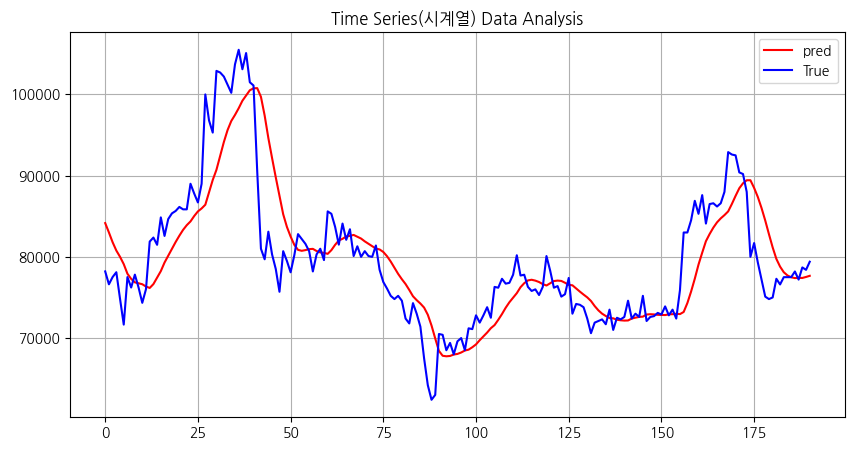

In [ ]:
import koreanize_matplotlib

# 시계열 데이터 얼마나 정확하게 맞췄는지 시각화
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(pred_inverse)), pred_inverse, label="pred", color="r")
plt.plot(np.arange(len(y_test_inverse)), y_test_inverse, label="True", color="b")
plt.legend()
plt.title("Time Series(시계열) Data Analysis")
plt.grid()
plt.show()